In [1]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

from DoE import standardize, dispersion, model_matrix, hadamard
sns.set_theme()

# Weighing 5 objets

In [2]:
def analyze(E, title=None):
    """
    1. Standardize the experiment matrix
    2. Build the model matrix
    3. compute the dispersion matrix
    """

    E = standardize(E)
    vars = [f"x{i+1}" for i in range(E.shape[1])]
    # M = Formula("1~x1+x2+x3+x4+x5").get_model_matrix(E)
    M = model_matrix("+".join(vars), pd.DataFrame(E, columns=vars))
    D = dispersion(M)

    print("Standardization of the experiment matrix E")
    print(E)
    print("Dispersion matrix D")
    print(D)

    plt.bar(np.arange(np.min(D.shape)), np.diagonal(D))
    plt.xlabel("Coefficients")
    plt.ylabel("Diagonal elements of the dispersion matrix")
    plt.ylim(0, 4)
    if title is not None:
        plt.title(title)
    plt.show()

    return np.trace(D), np.linalg.det(D)

tr  = np.zeros(8)
det = np.zeros(8)

## Strategy 1 (Offset, and then one by one)

Standardization of the experiment matrix E
[[-1. -1. -1. -1. -1.]
 [ 1. -1. -1. -1. -1.]
 [-1.  1. -1. -1. -1.]
 [-1. -1.  1. -1. -1.]
 [-1. -1. -1.  1. -1.]
 [-1. -1. -1. -1.  1.]]
Dispersion matrix D
[[3.5  1.   1.   1.   1.   1.  ]
 [1.   0.5  0.25 0.25 0.25 0.25]
 [1.   0.25 0.5  0.25 0.25 0.25]
 [1.   0.25 0.25 0.5  0.25 0.25]
 [1.   0.25 0.25 0.25 0.5  0.25]
 [1.   0.25 0.25 0.25 0.25 0.5 ]]


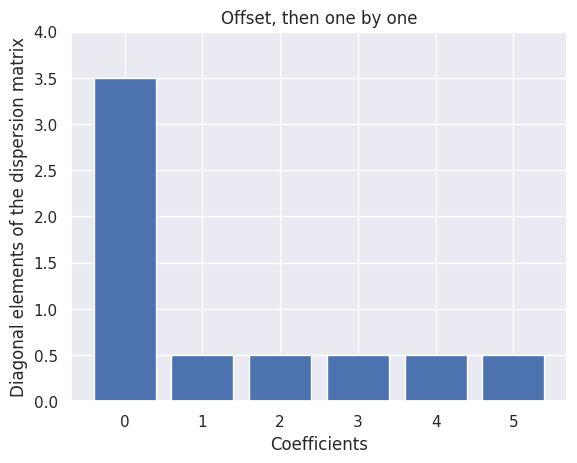

In [3]:
E0 = np.vstack((np.zeros(5), np.eye(5)))  # Experiment matrix
tr[0], det[0] = analyze(E0, title="Offset, then one by one")

## Strategy 2 (All, then one by one)

Standardization of the experiment matrix E
[[ 1.  1.  1.  1.  1.]
 [ 1. -1. -1. -1. -1.]
 [-1.  1. -1. -1. -1.]
 [-1. -1.  1. -1. -1.]
 [-1. -1. -1.  1. -1.]
 [-1. -1. -1. -1.  1.]]
Dispersion matrix D
[[ 0.21875  0.03125  0.03125  0.03125  0.03125  0.03125]
 [ 0.03125  0.21875 -0.03125 -0.03125 -0.03125 -0.03125]
 [ 0.03125 -0.03125  0.21875 -0.03125 -0.03125 -0.03125]
 [ 0.03125 -0.03125 -0.03125  0.21875 -0.03125 -0.03125]
 [ 0.03125 -0.03125 -0.03125 -0.03125  0.21875 -0.03125]
 [ 0.03125 -0.03125 -0.03125 -0.03125 -0.03125  0.21875]]


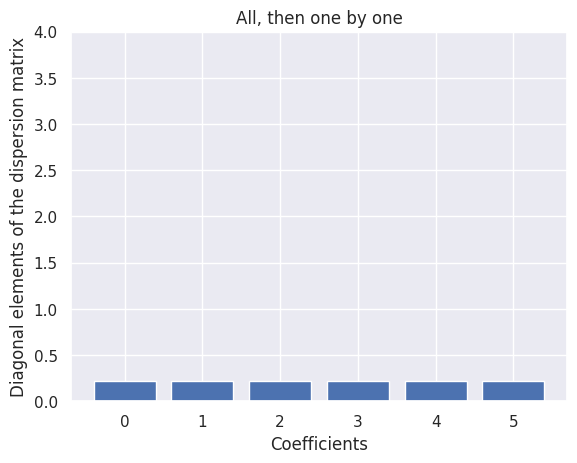

In [4]:
E1 = np.vstack((np.ones(5), np.eye(5)))
tr[1], det[1] = analyze(E1, title="All, then one by one")

## Strategy 3 (Offset, then all but one)

Standardization of the experiment matrix E
[[-1. -1. -1. -1. -1.]
 [-1.  1.  1.  1.  1.]
 [ 1. -1.  1.  1.  1.]
 [ 1.  1. -1.  1.  1.]
 [ 1.  1.  1. -1.  1.]
 [ 1.  1.  1.  1. -1.]]
Dispersion matrix D
[[ 0.21875 -0.03125 -0.03125 -0.03125 -0.03125 -0.03125]
 [-0.03125  0.21875 -0.03125 -0.03125 -0.03125 -0.03125]
 [-0.03125 -0.03125  0.21875 -0.03125 -0.03125 -0.03125]
 [-0.03125 -0.03125 -0.03125  0.21875 -0.03125 -0.03125]
 [-0.03125 -0.03125 -0.03125 -0.03125  0.21875 -0.03125]
 [-0.03125 -0.03125 -0.03125 -0.03125 -0.03125  0.21875]]


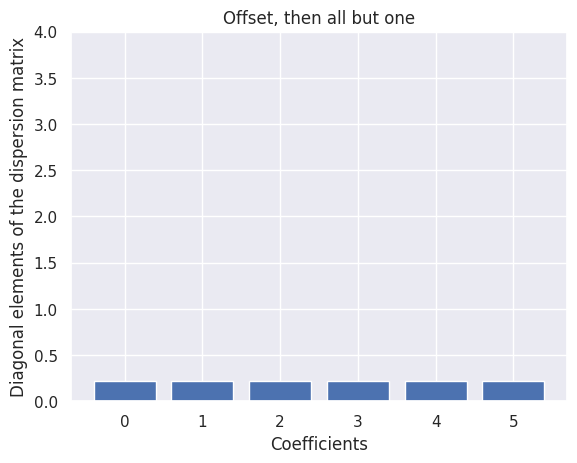

In [5]:
E2 = np.vstack((np.zeros(5), 1-np.eye(5)))
tr[2], det[2] = analyze(E2, title="Offset, then all but one")

## Strategy 4 (Offset, then two by two)

Standardization of the experiment matrix E
[[-1. -1. -1. -1. -1.]
 [ 1.  1. -1. -1. -1.]
 [-1.  1.  1. -1. -1.]
 [-1. -1.  1.  1. -1.]
 [-1. -1. -1.  1.  1.]
 [ 1. -1. -1. -1.  1.]]
Dispersion matrix D
[[ 0.375  0.125  0.125  0.125  0.125  0.125]
 [ 0.125  0.375 -0.125  0.125  0.125 -0.125]
 [ 0.125 -0.125  0.375 -0.125  0.125  0.125]
 [ 0.125  0.125 -0.125  0.375 -0.125  0.125]
 [ 0.125  0.125  0.125 -0.125  0.375 -0.125]
 [ 0.125 -0.125  0.125  0.125 -0.125  0.375]]


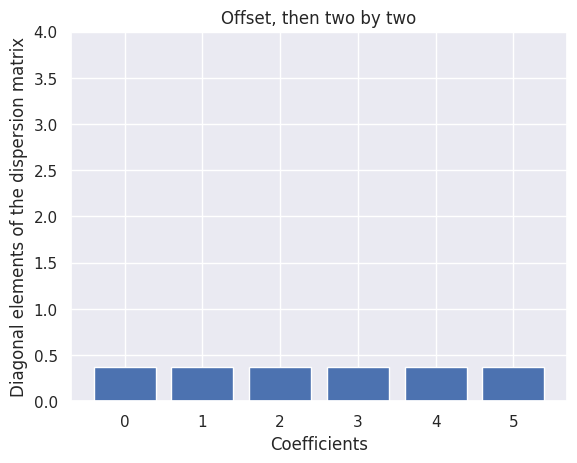

In [6]:
E3 = np.array([
    [0, 0, 0, 0, 0],
    [1, 1, 0, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0],
    [0, 0, 0, 1, 1],
    [1, 0, 0, 0, 1],
])
tr[3], det[3] = analyze(E3, title="Offset, then two by two")

## Strategy 5 (All, then two by two)

Standardization of the experiment matrix E
[[ 1.  1.  1.  1.  1.]
 [ 1.  1. -1. -1. -1.]
 [-1.  1.  1. -1. -1.]
 [-1. -1.  1.  1. -1.]
 [-1. -1. -1.  1.  1.]
 [ 1. -1. -1. -1.  1.]]
Dispersion matrix D
[[ 0.16666667  0.          0.          0.          0.          0.        ]
 [ 0.          0.33333333 -0.16666667  0.08333333  0.08333333 -0.16666667]
 [ 0.         -0.16666667  0.33333333 -0.16666667  0.08333333  0.08333333]
 [ 0.          0.08333333 -0.16666667  0.33333333 -0.16666667  0.08333333]
 [ 0.          0.08333333  0.08333333 -0.16666667  0.33333333 -0.16666667]
 [ 0.         -0.16666667  0.08333333  0.08333333 -0.16666667  0.33333333]]


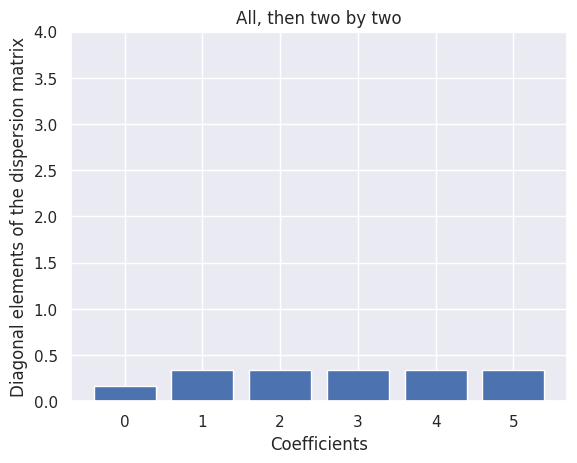

In [7]:
E4 = np.array([
    [1, 1, 1, 1, 1],
    [1, 1, 0, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0],
    [0, 0, 0, 1, 1],
    [1, 0, 0, 0, 1],
])
tr[4], det[4] = analyze(E4, title="All, then two by two")

## Strategy 6 (Offset, then three by three)

Standardization of the experiment matrix E
[[-1. -1. -1. -1. -1.]
 [ 1.  1.  1. -1. -1.]
 [-1.  1.  1.  1. -1.]
 [-1. -1.  1.  1.  1.]
 [ 1. -1. -1.  1.  1.]
 [ 1.  1. -1. -1.  1.]]
Dispersion matrix D
[[ 0.16666667  0.          0.          0.          0.          0.        ]
 [ 0.          0.33333333 -0.16666667  0.08333333  0.08333333 -0.16666667]
 [ 0.         -0.16666667  0.33333333 -0.16666667  0.08333333  0.08333333]
 [ 0.          0.08333333 -0.16666667  0.33333333 -0.16666667  0.08333333]
 [ 0.          0.08333333  0.08333333 -0.16666667  0.33333333 -0.16666667]
 [ 0.         -0.16666667  0.08333333  0.08333333 -0.16666667  0.33333333]]


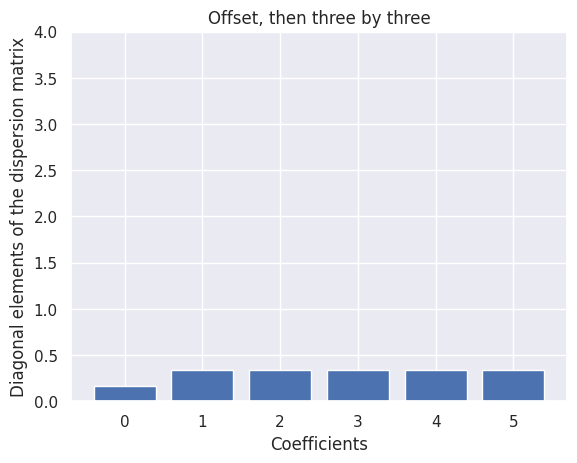

In [8]:
E5 = np.array([
    [0, 0, 0, 0, 0],
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [1, 0, 0, 1, 1],
    [1, 1, 0, 0, 1],
])
tr[5], det[5] = analyze(E5, title="Offset, then three by three")

## Strategy 7 (All, then three by three)

Standardization of the experiment matrix E
[[ 1.  1.  1.  1.  1.]
 [ 1.  1.  1. -1. -1.]
 [-1.  1.  1.  1. -1.]
 [-1. -1.  1.  1.  1.]
 [ 1. -1. -1.  1.  1.]
 [ 1.  1. -1. -1.  1.]]
Dispersion matrix D
[[ 0.375 -0.125 -0.125 -0.125 -0.125 -0.125]
 [-0.125  0.375 -0.125  0.125  0.125 -0.125]
 [-0.125 -0.125  0.375 -0.125  0.125  0.125]
 [-0.125  0.125 -0.125  0.375 -0.125  0.125]
 [-0.125  0.125  0.125 -0.125  0.375 -0.125]
 [-0.125 -0.125  0.125  0.125 -0.125  0.375]]


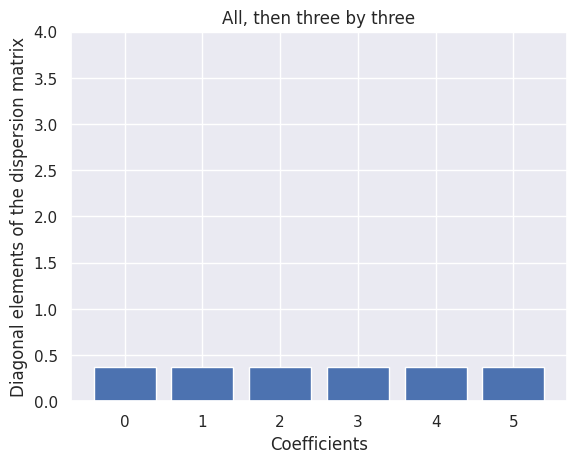

In [9]:
E6 = np.array([
    [1, 1, 1, 1, 1],
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [1, 0, 0, 1, 1],
    [1, 1, 0, 0, 1],
])
tr[6], det[6] = analyze(E6, title="All, then three by three")

## Strategy 8 (5 columns of an Hadamard matrix)

Standardization of the experiment matrix E
[[ 1.  1.  1.  1.  1.  1.  1.]
 [-1.  1. -1.  1. -1.  1. -1.]
 [ 1. -1. -1.  1.  1. -1. -1.]
 [-1. -1.  1.  1. -1. -1.  1.]
 [ 1.  1.  1. -1. -1. -1. -1.]
 [-1.  1. -1. -1.  1. -1.  1.]
 [ 1. -1. -1. -1. -1.  1.  1.]
 [-1. -1.  1. -1.  1.  1. -1.]]
Dispersion matrix D
[[0.125 0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.125 0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.125 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.125 0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.125 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.125 0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.125 0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.125]]


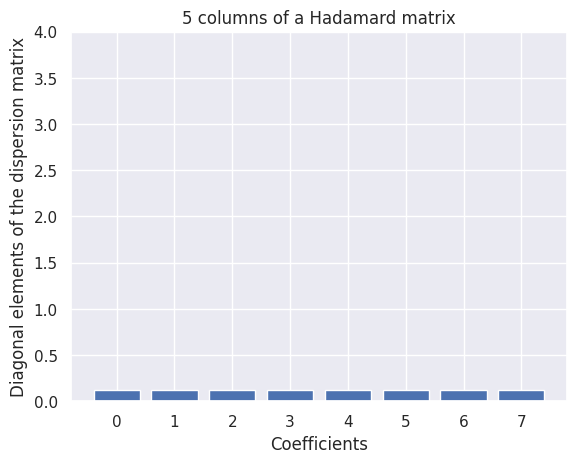

In [10]:
E7 = hadamard(8)[:, 1:]
tr[7], det[7] = analyze(E7, title="5 columns of a Hadamard matrix")

## Balance
### Evolution of the trace

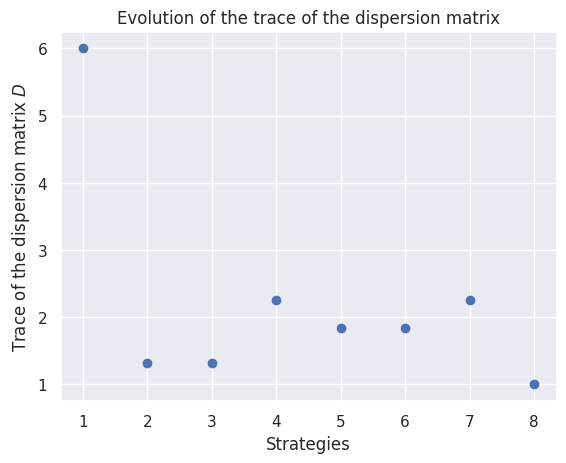

In [11]:
plt.scatter(np.arange(8)+1, tr)
plt.xlabel("Strategies")
plt.ylabel("Trace of the dispersion matrix $D$")
plt.title("Evolution of the trace of the dispersion matrix")
plt.show()

### How does the determinant evolve ?

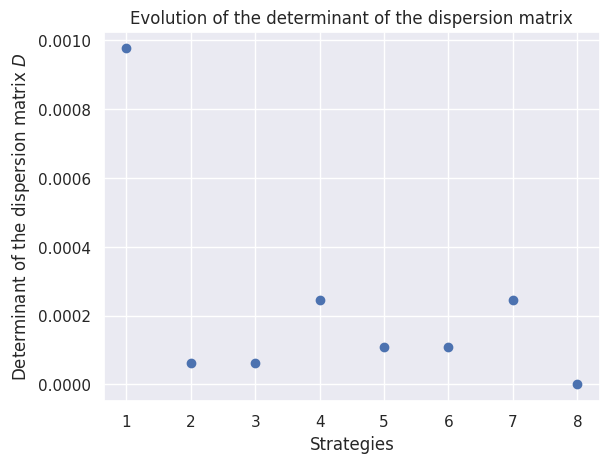

In [12]:
plt.scatter(np.arange(8)+1, det)
plt.xlabel("Strategies")
plt.ylabel("Determinant of the dispersion matrix $D$")
plt.title("Evolution of the determinant of the dispersion matrix")
plt.show()

## Conclusion

1. Strategies 2 and 3 are the best for 6 experiments.
2. Strategy 8 (Hadamard) is optimal with 8 experiments.